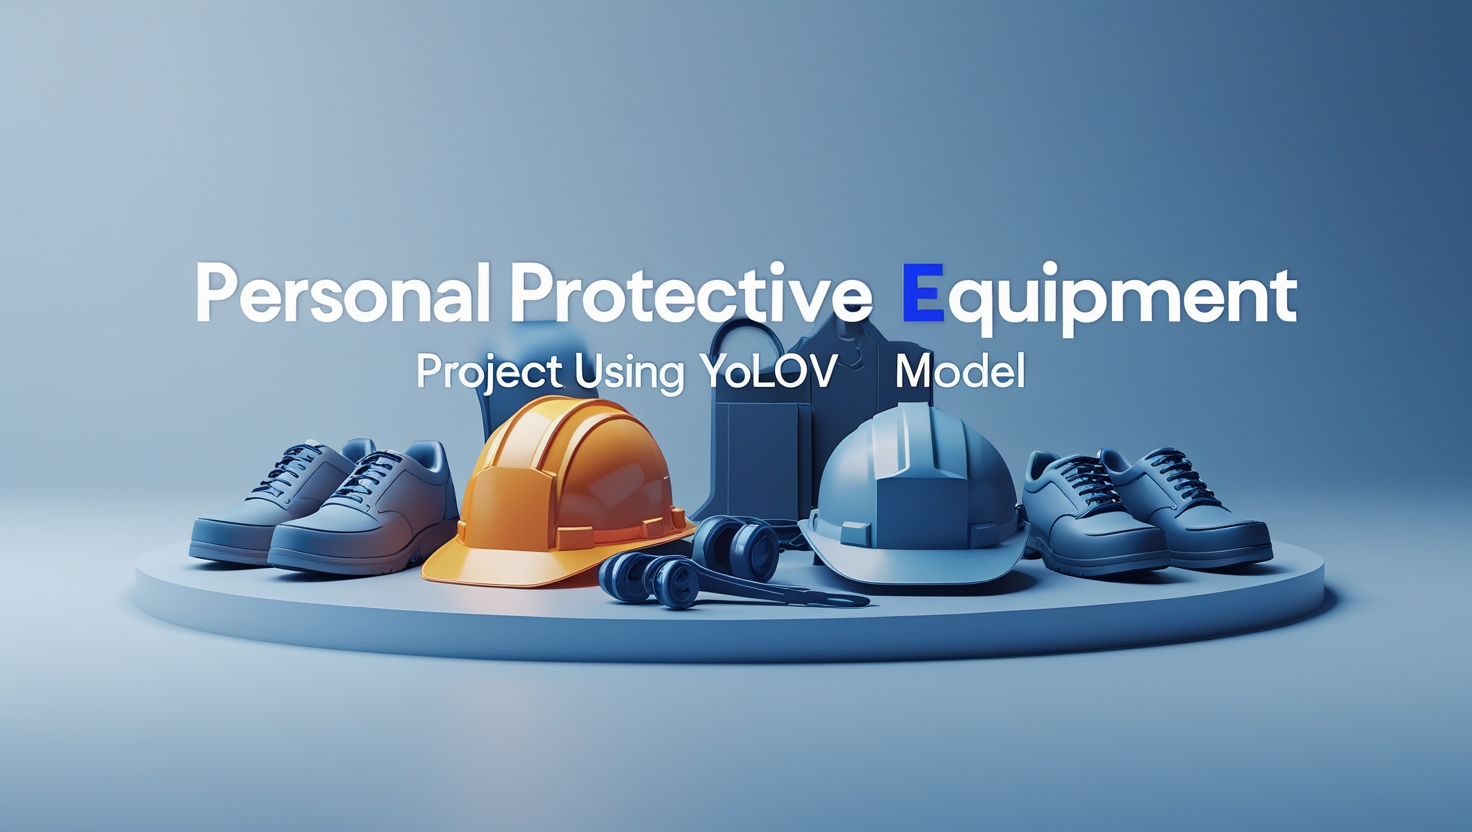

# Personal Protective Equipment Detection using YOLOv11


This notebook demonstrates how to detect Personal Protective Equipment (PPE) such as ['Boots', 'Ear-protection', 'Glass', 'Glove', 'Helmet', 'Mask', 'Person', 'Vest'] using the YOLOv11 object detection model.

## Step 1: Install Required Packages
We begin by installing the [Ultralytics](https://github.com/ultralytics/ultralytics) YOLOv11 library.

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

## Run Environment Checks
We verify if the YOLO library and dependencies are properly installed.

In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.7/112.6 GB disk)


## Step 2: Import Required Modules for YOLOv11 and Visualization
We import the YOLOv11 model class from the Ultralytics library.

In [3]:
from ultralytics import YOLO
from IPython.display import Image

## Step 3: Download PPE Dataset from Roboflow

In this step, we use the [Roboflow](https://roboflow.com) Python API to download a custom PPE (Personal Protective Equipment) dataset that has been pre-annotated for object detection.

The following tasks are performed:
- Install the Roboflow Python client
- Authenticate using your Roboflow API key
- Access a specific project and version hosted under the workspace `badminton-szmsf`
- Download the dataset in the **YOLOv11 format** for training

Once downloaded, the dataset is extracted and ready to be used with YOLOv11 training.


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="PqF6HU4FUT9iaWwYC0Yu")
project = rf.workspace("badminton-szmsf").project("safety-pyazl-6lzii")
version = project.version(1)
dataset = version.download("yolov11")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to safety-1 in yolov11:: 100%|██████████| 1212/1212 [00:00<00:00, 7526.57it/s]


In [ ]:
dataset.location

- change the paths of image folder in .yaml file

## Step 4: Model Training.


In [ ]:
!yolo task = detect mode = train data = {dataset.location}/data.yaml model = "yolo11n.pt" epochs = 100 imgsz = 640

## Step 5: Model Evaluation.


In [ ]:
Image(r"/content/runs/detect/train/confusion_matrix.png", width= 800)

In [ ]:
Image(r"/content/runs/detect/train/labels.jpg", width=600)

In [ ]:
Image("/content/runs/detect/train/results.png", width=1000)

In [ ]:
!yolo task=detect mode=val model="/content/runs/detect/train/weights/best.pt" data="/content/safety-1/data.yaml"

In [ ]:
!yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source="/content/safety-1/test/images" save=True

## Step 6: Display Prediction Results

After running inference, YOLOv11 saves the prediction images (with bounding boxes) in the `runs/detect/predict/` folder.

In this step, we:
- Find the latest prediction folder
- Load the top few `.jpg` prediction images
- Display them inline to visualize the results


In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob("/content/runs/detect/predict/"), key=os.path.getmtime)
for img in glob.glob("f{latest_folder}/*.jpg")[1:4]:
  display(IPyImage(filename=img, width=600))
  print("/n")



## Step 7: Run Inference using YOLOv11 Model

In this step, we use the trained YOLOv11 model (`best.pt`) to detect objects on a test image (`0.jpg`).  
The command sets a confidence threshold of **0.25**, and saves the output with detected bounding boxes.

- **Model**: `/content/runs/detect/train/weights/best.pt` (YOLOv11 trained weights)  
- **Image Source**: `/content/0.jpg`  
- **Confidence Threshold**: `0.25`  
- **Output Folder**: Automatically saved in `runs/detect/predict/`


Visualize YOLOv11 Prediction Output

In [ ]:
!yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source="/content/0.jpg" save=True

In [ ]:
Image("/content/runs/detect/predict2/0.jpg", width=600)

## Step 7 (Alternate): Run Inference on a Video using YOLOv11

In this step, we use the trained YOLOv11 model to perform object detection on a video file (`videoplayback.avi`).  
The prediction results (bounding boxes and labels) will be rendered frame by frame and saved as a new video in the `runs/detect/predict/` directory.

- **Model**: `/content/runs/detect/train/weights/best.pt`  
- **Video Source**: `/content/videoplayback.avi`  
- **Confidence Threshold**: `0.25`  
- **Output**: Annotated video saved automatically


In [ ]:
!yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" source="/content/videoplayback.avi" conf=0.25 save=True

## Step 8: Compress and Display YOLOv11 Inference Video

After running inference on a video file, YOLOv11 saves the output in `.avi` format, which may not play smoothly in web interfaces like Jupyter/Colab.

In this step, we:
- Convert the `.avi` output video to `.mp4` format using **FFmpeg** for better compatibility
- Encode the `.mp4` as Base64
- Embed and display the video directly within the notebook using HTML

This provides a smooth, inline preview of detection results on the full video.


In [ ]:
from IPython.display import HTML
from base64 import b64encode
import os

save_path = "/content/runs/detect/predict3/videoplayback.avi"

compress_path = "/content/videoplayback.mp4"

os.system(f"ffmpeg -i {save_path} -vcodec libx264 {compress_path}")

mp4 = open(compress_path, "rb").read()

data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML("""
<video width=400 controls>
  <source src="%s" type="video/mp4">
</video>
""" % data_url)


In [ ]:
!pip install streamlit

## Step 9: Zip and Download YOLOv11 Results Folder via Streamlit

To simplify access to the detection results (images, videos, logs, etc.), we provide an option to **zip the entire `/runs` folder** and enable users to **download it directly** from the Streamlit app.

This step includes:
- Recursively zipping the contents of the `/runs` directory (which contains training and prediction outputs)
- Displaying a download button in the Streamlit UI for users to get the zipped file

Click the **"📦 Download Results Folder"** button to save your detection results locally.


In [ ]:
import streamlit as st
import zipfile
import os
from io import BytesIO

def zip_folder(folder_path):
    """Zips the contents of a folder and returns it as a BytesIO object"""
    zip_buffer = BytesIO()
    with zipfile.ZipFile(zip_buffer, "w", zipfile.ZIP_DEFLATED) as zip_file:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, start=folder_path)
                zip_file.write(file_path, arcname)
    zip_buffer.seek(0)
    return zip_buffer

# Example usage
folder_to_zip = "/content/runs"  # Replace with your folder path

if os.path.exists(folder_to_zip):
    zipped_folder = zip_folder(folder_to_zip)

    st.download_button(
        label="📦 Download Results Folder",
        data=zipped_folder,
        file_name="runs.zip",
        mime="application/zip"
    )
else:
    st.warning(f"Folder '{folder_to_zip}' not found.")


## Step 10 (Alternate): Zip and Download Results Folder in Google Colab

If you're working in Google Colab, you can use this method to download the entire `/runs` directory, which contains all YOLOv11 outputs (e.g., training logs, prediction images, videos).

This step does the following:
- Zips the entire `/content/runs` folder
- Generates a `runs.zip` file in `/content`
- Automatically triggers a download prompt to save the file locally

This provides a quick and convenient way to retrieve all output files from Colab.


In [ ]:
import shutil
from google.colab import files

# Path to the folder you want to zip
folder_path = "/content/runs"
zip_path = "/content/runs.zip"

# Zip the folder
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', folder_path)

# Download the zipped file
files.download(zip_path)


## Step 11: Zip a Folder Programmatically (Local/Colab)

This utility function allows you to programmatically zip any folder using Python’s built-in `zipfile` module.  
In this example, we zip the folder named `safety-1` and create a compressed archive `safety-1.zip`.

This is useful for:
- Packaging datasets or model outputs
- Archiving files for sharing or backup
- Preparing folders for upload or download

After running this code, the zip file will be created in the current working directory.


In [ ]:
import zipfile
import os

def zip_folder(folder_path, output_filename):
    with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, start=folder_path)
                zipf.write(file_path, arcname)
    print(f"Folder '{folder_path}' zipped as '{output_filename}'")

# Example usage
zip_folder('safety-1', 'safety-1.zip')


<hr>
